# Notebook 10 - Final Application

VisionNarrator | Stage 10

---

## 1. Project Overview

VisionNarrator turns a photograph into language at three levels — a caption, a structured understanding of the scene, and a grounded story — using models trained and evaluated in this repository.

| Stage | Notebook | Outcome |
|---|---|---|
| Data | 01–02 | Flickr30k explored, cleaned, split image-wise (22,248 / 4,767 / 4,768 images), preprocessing pipeline |
| Scratch ViT | 03–04 | Vision Transformer and caption decoder built from scratch (BLEU-4 0.10) |
| Transfer learning | 05 | Pretrained ViT-B/16 (ImageNet-21k) as encoder, frozen then fine-tuned (BLEU-4 0.25) |
| Pretrained decoder | 06 | Fine-tuned ViT → projection → GPT-2 with a 197-token visual prefix, three-phase training (BLEU-4 0.27, CIDEr 0.60) |
| Evaluation | 07 | BLEU / METEOR / ROUGE-L / CIDEr on 4,768 test images, failure, length and confidence analysis |
| Semantic understanding | 08 | Entities, actions, attributes, scene and relationships extracted from captions; consistency checks; story inputs |
| Story generation | 09 | Short description, explanation and story from a local instruction-tuned LLM with a grounding / repair loop |
| **Final application** | **10** | **One pipeline function: image → caption → semantics → story, with output modes, error handling and performance analysis** |

Everything runs locally: the captioner (~211M parameters) and the story model (Qwen2.5-1.5B-Instruct) fit together on an 8 GB GPU.


## 2. System Architecture

```
                         IMAGE (path / PIL / array)
                                   │
                    ┌──────────────▼──────────────┐
                    │  Preprocessing               │  RGB → 224×224 → normalize (mean/std from checkpoint)
                    └──────────────┬──────────────┘
                                   │ (1, 3, 224, 224)
                    ┌──────────────▼──────────────┐
                    │  ViT-B/16 (fine-tuned)       │  197 visual tokens × 768, CLS attention map
                    └──────────────┬──────────────┘
                                   │ (1, 197, 768)
                    ┌──────────────▼──────────────┐
                    │  Visual projection           │  768 → 768 → 768 (GELU), GPT-2 hidden space
                    └──────────────┬──────────────┘
                                   │ visual prefix
                    ┌──────────────▼──────────────┐
                    │  GPT-2 decoder               │  beam search → caption + token probabilities
                    └──────────────┬──────────────┘
                                   │ caption
                    ┌──────────────▼──────────────┐
                    │  Semantic layer (spaCy)      │  entities · actions · attributes · scene · relations
                    │  src/semantics.py            │  consistency flags · confidence · prompt block
                    └──────────────┬──────────────┘
                                   │ structured record
                    ┌──────────────▼──────────────┐
                    │  Story model (Qwen2.5-1.5B)  │  short description · explanation · story
                    │  src/storytelling.py         │  grounding check → repair pass
                    └──────────────┬──────────────┘
                                   │
                 caption · record · description · explanation · story
```

| Component | Source | Parameters | GPU memory | File |
|---|---|---|---|---|
| ViT-B/16 encoder | google/vit-base-patch16-224-in21k, fine-tuned (NB 05/06) | 86M | ~0.35 GB | src/models/vit_gpt2_captioner.pt |
| Visual projection | trained (NB 06) | 1.2M | – | same file |
| GPT-2 decoder | gpt2, fine-tuned (NB 06) | 124M | ~0.5 GB | same file |
| Semantic layer | spaCy en_core_web_sm + lexicons (NB 08) | 12M | CPU | src/semantics.py |
| Story model | Qwen/Qwen2.5-1.5B-Instruct (NB 09) | 1.5B | ~3.1 GB (fp16) | Hugging Face cache |


## 3. Import Dependencies

Standard library · NumPy / Pandas / Matplotlib · PIL · Torch / Torchvision · Transformers · spaCy
src/semantics.py · src/storytelling.py


In [1]:
import io
import json
import math
import subprocess
import sys
import tempfile
import time
import traceback
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError

import torch
import torch.nn as nn
from torchvision import transforms as T
import transformers
from transformers import ViTModel, ViTConfig, GPT2LMHeadModel, GPT2Config, GPT2TokenizerFast
import spacy

def resolve_base_dir() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "src" / "data").exists():
        return cwd
    if (cwd.parent / "src" / "data").exists():
        return cwd.parent
    return cwd

BASE_DIR = resolve_base_dir()
sys.path.insert(0, str(BASE_DIR))

from src import semantics as sem
from src.storytelling import StoryGenerator, Grounder, STORY_STRUCTURE

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 20)
pd.set_option("display.max_colwidth", 90)

print(f"torch {torch.__version__} | transformers {transformers.__version__} | spacy {spacy.__version__}")
print(f"BASE_DIR: {BASE_DIR}")


c:\Users\vishe\OneDrive\Desktop\VisionNarrator\VisionNarrator\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch 2.13.0+cu130 | transformers 5.15.0 | spacy 3.8.15
BASE_DIR: C:\Users\vishe\OneDrive\Desktop\VisionNarrator\VisionNarrator


## 4. Load Configuration

Paths, the captioner's own config (read from its checkpoint so preprocessing and decoding match training), story-model settings, output modes and the device.

CAPTIONER_FILE = vit_gpt2_captioner.pt
STORY_MODEL_NAME = Qwen/Qwen2.5-1.5B-Instruct
NUM_BEAMS / MAX_NEW_TOKENS / NO_REPEAT_NGRAM → from checkpoint
TEMPERATURE = 0.6 · TOP_P = 0.9 · SEED = 42 · MAX_REPAIRS = 1 · MIN_ENTITY_COVERAGE = 0.5
OUTPUT_MODES = caption · describe · explain · story · structured

Memory: captioner ~1.5 GB + story model ~3.1 GB on the GPU. Close other notebook kernels first.


In [2]:
CONFIG = {
    "paths": {
        "data": BASE_DIR / "src" / "data",
        "demo": BASE_DIR / "src" / "data" / "demo",
        "models": BASE_DIR / "src" / "models",
        "results": BASE_DIR / "results",
        "docs": BASE_DIR / "docs",
    },
    "captioner_file": "vit_gpt2_captioner.pt",
    "story_model_name": "Qwen/Qwen2.5-1.5B-Instruct",
    "story": {"temperature": 0.6, "top_p": 0.9, "seed": 42, "max_repairs": 1, "min_entity_coverage": 0.5, "uncertain_below": 0.3},
    "output_modes": {
        "caption": ["caption"],
        "describe": ["caption", "semantics", "short_description"],
        "explain": ["caption", "semantics", "short_description", "detailed_explanation"],
        "story": ["caption", "semantics", "short_description", "detailed_explanation", "story"],
        "structured": ["caption", "semantics"],
    },
}

captioner_checkpoint = torch.load(CONFIG["paths"]["models"] / CONFIG["captioner_file"], map_location="cpu")
CONFIG["captioner"] = dict(captioner_checkpoint["config"])
CONFIG["captioner"]["best_phase"] = captioner_checkpoint["best_phase"]
CONFIG["captioner"]["val_loss"] = round(float(captioner_checkpoint["best_val_loss"]), 4)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CONFIG["device"] = str(device)

print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)} | {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    try:
        query = subprocess.run(["nvidia-smi", "--query-gpu=memory.used,memory.total", "--format=csv,noheader,nounits"], capture_output=True, text=True, check=True)
        used_mib, total_mib = (int(v) for v in query.stdout.strip().split(","))
        print(f"GPU memory in use before this notebook: {used_mib:,} / {total_mib:,} MiB")
        if used_mib > 2048:
            print("WARNING: more than 2 GB already in use - close other notebook kernels before loading the models")
    except Exception as error:
        print(f"nvidia-smi not available: {error}")

print()
print("Captioner config:", json.dumps(CONFIG["captioner"], indent=2))
print("Story config:", CONFIG["story"])
print("Output modes:", {k: " → ".join(v) for k, v in CONFIG["output_modes"].items()})


Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU | 8.6 GB
GPU memory in use before this notebook: 189 / 8,188 MiB

Captioner config: {
  "vit_model_name": "google/vit-base-patch16-224-in21k",
  "gpt2_model_name": "gpt2",
  "img_size": 224,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "prefix_len": 197,
  "dropout": 0.1,
  "max_tokens": 40,
  "num_beams": 5,
  "max_new_tokens": 30,
  "no_repeat_ngram": 3,
  "best_phase": "phase3",
  "val_loss": 2.3656
}
Story config: {'temperature': 0.6, 'top_p': 0.9, 'seed': 42, 'max_repairs': 1, 'min_entity_coverage': 0.5, 'uncertain_below': 0.3}
Output modes: {'caption': 'caption', 'describe': 'caption → semantics → short_description', 'explain': 'caption → semantics → short_description → detailed_explanation', 'story': 'caption → semantics → short_description → detailed_explanation → story', 'structured': 'caption → semantics'}


## 5. Load All Trained Components

captioner → ViT (eager attention) + projection + GPT-2, weights from the checkpoint, GPT-2 tokenizer
semantic layer → spaCy pipeline through src/semantics.py
story model → StoryGenerator (fp16 on GPU) + Grounder from src/storytelling.py

A component table records parameters, disk size, device and load time.


In [3]:
class VisualProjection(nn.Module):
    def __init__(self, vit_dim=768, gpt2_dim=768, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(vit_dim, gpt2_dim)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(gpt2_dim, gpt2_dim)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        return self.drop(self.fc2(self.act(self.fc1(x))))

class VisionNarrator(nn.Module):
    def __init__(self, vit, projection, gpt2):
        super().__init__()
        self.vit = vit
        self.projection = projection
        self.gpt2 = gpt2

    def encode_images(self, images, return_attention=False):
        outputs = self.vit(pixel_values=images, output_attentions=return_attention)
        prefix = self.projection(outputs.last_hidden_state)
        if return_attention:
            return prefix, outputs.last_hidden_state, outputs.attentions[-1][:, :, 0, 1:].mean(dim=1)
        return prefix

    def forward(self, images, input_ids, attention_mask):
        prefix = self.encode_images(images)
        text_embeds = self.gpt2.transformer.wte(input_ids)
        inputs_embeds = torch.cat([prefix, text_embeds], dim=1)
        prefix_mask = torch.ones(prefix.shape[:2], dtype=attention_mask.dtype, device=attention_mask.device)
        hidden = self.gpt2.transformer(inputs_embeds=inputs_embeds, attention_mask=torch.cat([prefix_mask, attention_mask], dim=1)).last_hidden_state
        return self.gpt2.lm_head(hidden[:, prefix.shape[1] - 1 : -1])

components = []
cap_cfg = CONFIG["captioner"]

start = time.time()
captioner = VisionNarrator(
    ViTModel(ViTConfig.from_pretrained(cap_cfg["vit_model_name"], attn_implementation="eager"), add_pooling_layer=False),
    VisualProjection(dropout=cap_cfg["dropout"]),
    GPT2LMHeadModel(GPT2Config.from_pretrained(cap_cfg["gpt2_model_name"])),
)
captioner.load_state_dict(captioner_checkpoint["model_state"], strict=True)
captioner = captioner.to(device).eval()
for p in captioner.parameters():
    p.requires_grad = False
cap_tokenizer = GPT2TokenizerFast.from_pretrained(cap_cfg["gpt2_model_name"])
cap_tokenizer.pad_token = cap_tokenizer.eos_token
EOS_ID = cap_tokenizer.eos_token_id
captioner_seconds = time.time() - start
captioner_size_mb = (CONFIG["paths"]["models"] / CONFIG["captioner_file"]).stat().st_size / 1e6
components.append({"component": "captioner (ViT + projection + GPT-2)", "parameters": sum(p.numel() for p in captioner.parameters()), "disk MB": round(captioner_size_mb), "device": str(device), "load s": round(captioner_seconds, 1)})

start = time.time()
nlp = sem.load_nlp()
components.append({"component": f"semantic layer (spaCy {nlp.meta['name']})", "parameters": None, "disk MB": None, "device": "cpu", "load s": round(time.time() - start, 1)})

story = StoryGenerator(CONFIG["story_model_name"], device=device, temperature=CONFIG["story"]["temperature"], top_p=CONFIG["story"]["top_p"], seed=CONFIG["story"]["seed"])
grounder = Grounder(nlp, min_entity_coverage=CONFIG["story"]["min_entity_coverage"], max_repairs=CONFIG["story"]["max_repairs"])
components.append({"component": f"story model ({CONFIG['story_model_name']})", "parameters": story.num_parameters, "disk MB": None, "device": str(story.device) if story.available else "unavailable", "load s": round(story.load_seconds, 1)})

components_df = pd.DataFrame(components)
display(components_df)
if not story.available:
    print(f"Story model unavailable: {story.error} - descriptions fall back to the caption / prompt block")
if device.type == "cuda":
    print(f"GPU memory allocated after loading: {torch.cuda.memory_allocated() / 1e9:.2f} GB")


Loading weights: 100%|██████████| 338/338 [00:02<00:00, 144.54it/s]


,component,parameters,disk MB,device,load s
0,captioner (ViT + projection + GPT-2),2.114196e+08,846.0,cuda,4.6
1,semantic layer (spaCy core_web_sm),NaN,NaN,cpu,0.2
2,story model (Qwen/Qwen2.5-1.5B-Instruct),1.543714e+09,NaN,cuda,5.8


GPU memory allocated after loading: 3.93 GB


## 6. Image Preprocessing

path / PIL image / NumPy array
      ↓
RGB (grayscale, RGBA, palette and CMYK inputs are converted)
      ↓
Resize 224×224 → ToTensor → Normalize (checkpoint mean / std)
      ↓
(1, 3, 224, 224)

`load_image` validates the input and raises a clear error for missing files or non-image data; `preprocess` returns the tensor and keeps the original PIL image for display.


Sample: 1089755335.jpg | original (500, 336) RGB | tensor (1, 3, 224, 224) range (-1.00, 1.00)


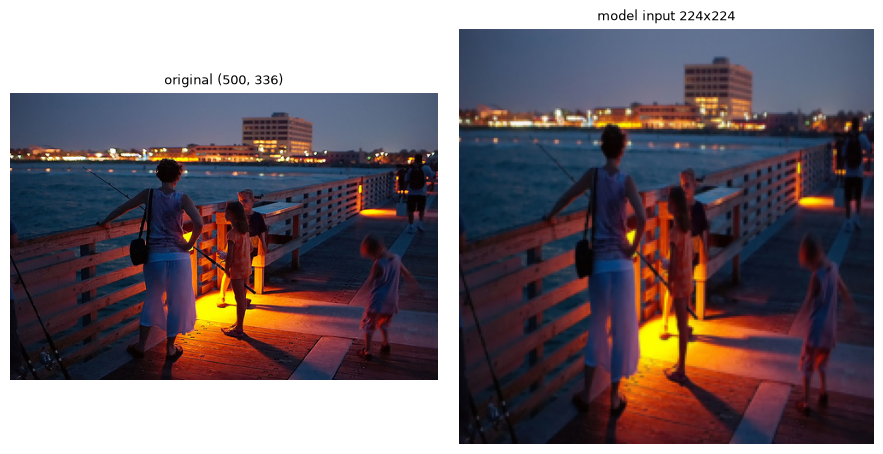

In [4]:
IMG_SIZE = cap_cfg["img_size"]
IMAGE_MEAN = cap_cfg["image_mean"]
IMAGE_STD = cap_cfg["image_std"]

image_transform = T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.ToTensor(), T.Normalize(mean=IMAGE_MEAN, std=IMAGE_STD)])

def load_image(source):
    if isinstance(source, Image.Image):
        image = source
    elif isinstance(source, np.ndarray):
        image = Image.fromarray(source)
    elif isinstance(source, (str, Path)):
        path = Path(source)
        if not path.exists():
            raise FileNotFoundError(f"image not found: {path}")
        try:
            image = Image.open(path)
            image.load()
        except (UnidentifiedImageError, OSError) as error:
            raise ValueError(f"not a readable image: {path.name} ({error})") from error
    else:
        raise TypeError(f"unsupported image source type: {type(source).__name__}")
    if image.width < 8 or image.height < 8:
        raise ValueError(f"image too small: {image.width}x{image.height}")
    return image.convert("RGB")

def preprocess(source):
    image = load_image(source)
    return image_transform(image).unsqueeze(0), image

def denormalize(pixels):
    array = pixels[0].cpu().clone()
    for channel, (mean, std) in enumerate(zip(IMAGE_MEAN, IMAGE_STD)):
        array[channel] = array[channel] * std + mean
    return array.clamp(0, 1).permute(1, 2, 0).numpy()

test_paths = pd.read_csv(CONFIG["paths"]["data"] / "test.csv").drop_duplicates(subset="image").set_index("image")["image_path"]
sample_path = Path(test_paths.iloc[40])
pixels, sample_image = preprocess(sample_path)

print(f"Sample: {sample_path.name} | original {sample_image.size} {sample_image.mode} | tensor {tuple(pixels.shape)} range ({pixels.min().item():.2f}, {pixels.max().item():.2f})")

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].imshow(sample_image)
axes[0].set_title(f"original {sample_image.size}", fontsize=9)
axes[1].imshow(denormalize(pixels))
axes[1].set_title(f"model input {IMG_SIZE}x{IMG_SIZE}", fontsize=9)
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()


## 7. Visual Encoding

(1, 3, 224, 224) → ViT → 197 tokens × 768 → projection → visual prefix 197 × 768 (GPT-2 space) + CLS attention map (14×14)

`encode_image` returns the prefix used by the decoder, the raw ViT tokens and the attention map; attention focus = share of attention in the 20 strongest patches.


ViT tokens: (1, 197, 768) | prefix: (1, 197, 768) | attention grid: (14, 14) | focus 0.591 | 331 ms
Token norm: ViT 5.37 | prefix 39.62 | GPT-2 word embeddings 3.96


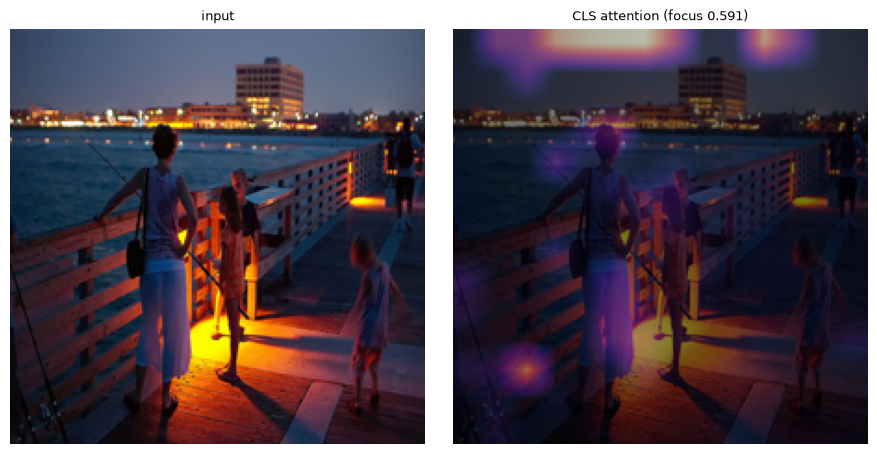

In [5]:
@torch.no_grad()
def encode_image(pixels):
    prefix, tokens, attention = captioner.encode_images(pixels.to(device), return_attention=True)
    grid = attention[0].reshape(14, 14).cpu().numpy()
    focus = float(np.sort(grid.flatten())[-20:].sum() / grid.sum())
    return {"prefix": prefix, "tokens": tokens, "attention": grid, "attention_focus": round(focus, 3)}

start = time.time()
encoding = encode_image(pixels)
encode_seconds = time.time() - start

print(f"ViT tokens: {tuple(encoding['tokens'].shape)} | prefix: {tuple(encoding['prefix'].shape)} | attention grid: {encoding['attention'].shape} | focus {encoding['attention_focus']} | {encode_seconds * 1000:.0f} ms")
print(f"Token norm: ViT {encoding['tokens'].norm(dim=-1).mean().item():.2f} | prefix {encoding['prefix'].norm(dim=-1).mean().item():.2f} | GPT-2 word embeddings {captioner.gpt2.transformer.wte.weight.norm(dim=-1).mean().item():.2f}")

heat = np.asarray(Image.fromarray((encoding["attention"] / encoding["attention"].max() * 255).astype(np.uint8)).resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)) / 255.0
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].imshow(sample_image.resize((IMG_SIZE, IMG_SIZE)))
axes[0].set_title("input", fontsize=9)
axes[1].imshow(sample_image.resize((IMG_SIZE, IMG_SIZE)))
axes[1].imshow(heat, cmap="magma", alpha=0.55)
axes[1].set_title(f"CLS attention (focus {encoding['attention_focus']})", fontsize=9)
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()


## 8. Caption Generation

visual prefix → `gpt2.generate(inputs_embeds=...)` → caption

Beam search (NUM_BEAMS from the checkpoint) is the default; greedy is available for speed and for the consistency check. `caption_pieces` re-scores the caption teacher-forced and returns each BPE piece with its probability and character span, which gives an overall caption confidence and per-word confidences for the semantic layer.


In [6]:
def encode_captions(caption_list):
    encoded = cap_tokenizer([c + cap_tokenizer.eos_token for c in caption_list], padding=True, truncation=True, max_length=cap_cfg["max_tokens"], return_tensors="pt")
    return encoded.input_ids, encoded.attention_mask

@torch.no_grad()
def generate_caption(prefix, num_beams=None):
    num_beams = cap_cfg["num_beams"] if num_beams is None else num_beams
    kwargs = dict(
        inputs_embeds=prefix,
        attention_mask=torch.ones(prefix.shape[:2], dtype=torch.long, device=device),
        max_new_tokens=cap_cfg["max_new_tokens"],
        do_sample=False,
        num_beams=num_beams,
        no_repeat_ngram_size=cap_cfg["no_repeat_ngram"],
        eos_token_id=EOS_ID,
        pad_token_id=EOS_ID,
    )
    if num_beams > 1:
        kwargs["early_stopping"] = True
    return cap_tokenizer.decode(captioner.gpt2.generate(**kwargs)[0], skip_special_tokens=True)

@torch.no_grad()
def caption_pieces(pixels, caption):
    input_ids, attention_mask = encode_captions([caption])
    logits = captioner(pixels.to(device), input_ids.to(device), attention_mask.to(device))
    probs = logits.softmax(dim=-1).gather(-1, input_ids.to(device).unsqueeze(-1)).squeeze(-1)[0].cpu()
    ids = input_ids[0].tolist()
    pieces, prev_end = [], 0
    for i in range(len(ids)):
        end = len(cap_tokenizer.decode(ids[: i + 1], skip_special_tokens=True))
        if end > prev_end:
            pieces.append({"start": prev_end, "end": end, "prob": round(float(probs[i]), 4)})
        prev_end = end
    confidence = float(np.exp(np.mean(np.log([max(p["prob"], 1e-6) for p in pieces])))) if pieces else 0.0
    return pieces, round(confidence, 3)

start = time.time()
caption_beam = generate_caption(encoding["prefix"])
beam_seconds = time.time() - start
start = time.time()
caption_greedy = generate_caption(encoding["prefix"], num_beams=1)
greedy_seconds = time.time() - start
pieces, confidence = caption_pieces(pixels, caption_beam)

print(f"Beam {cap_cfg['num_beams']} ({beam_seconds * 1000:.0f} ms): {caption_beam}")
print(f"Greedy ({greedy_seconds * 1000:.0f} ms):  {caption_greedy}")
print(f"Caption confidence (geometric mean token probability): {confidence}")
print("Pieces:", [(caption_beam[p['start']:p['end']], p['prob']) for p in pieces])


c:\Users\vishe\OneDrive\Desktop\VisionNarrator\VisionNarrator\venv\Lib\site-packages\transformers\generation\utils.py:1185: UserWarning: Passing `no_repeat_ngram_size` with `inputs_embeds` and without `input_ids` to `generate` will apply n-gram constraints only to newly generated tokens, not to the prompt.
  warnings.warn(


Beam 5 (531 ms): A man and a woman are standing on a pier looking at the water .
Greedy (149 ms):  A man and a woman are standing on a dock with a boat in the background .
Caption confidence (geometric mean token probability): 0.448
Pieces: [('A', 0.3368), (' man', 0.3403), (' and', 0.7257), (' a', 0.3831), (' woman', 0.7398), (' are', 0.349), (' standing', 0.2618), (' on', 0.4085), (' a', 0.6853), (' pier', 0.2833), (' looking', 0.225), (' at', 0.6893), (' the', 0.4158), (' water', 0.7675), (' .', 0.686)]


## 9. Semantic Analysis

caption (beam) → src/semantics.py → entities · actions · attributes · scene · relationships
caption (greedy) → second parse for the consistency check
token probabilities → confidence per entity and action → "(uncertain)" markers in the prompt block

`analyze_caption` returns the record that both the story model and the "structured" output mode consume.


In [7]:
def token_confidence(token, pieces):
    start, end = token.idx, token.idx + len(token.text)
    probs = [p["prob"] for p in pieces if p["end"] > start and p["start"] < end]
    return round(float(np.exp(np.mean(np.log([max(p, 1e-6) for p in probs])))), 3) if probs else None

def analyze_caption(image_name, caption, greedy_caption, pieces):
    rep = sem.build_representation(image_name, "app", caption)
    greedy_rep = sem.build_representation(image_name, "app", greedy_caption)
    rep["flags"], jaccard = sem.check_consistency(rep, greedy_rep)
    doc = nlp(caption)
    for entity in rep["entities"]:
        entity["confidence"] = token_confidence(doc[entity["token"]], pieces)
    for action in rep["actions"]:
        action["confidence"] = token_confidence(doc[action["token"]], pieces)
    prompt = sem.story_prompt(rep)
    return {
        "image": image_name,
        "source": "app",
        "caption": caption,
        "greedy_caption": greedy_caption,
        "semantics": {"entities": rep["entities"], "actions": rep["actions"], "attributes": rep["attributes"], "scene": rep["scene"], "relationships": rep["relationships"]},
        "flags": rep["flags"],
        "greedy_beam_entity_jaccard": jaccard,
        "prompt": prompt,
    }

start = time.time()
record = analyze_caption(sample_path.name, caption_beam, caption_greedy, pieces)
semantics_seconds = time.time() - start

print(f"Semantic analysis in {semantics_seconds * 1000:.0f} ms | flags: {record['flags'] or 'none'} | greedy/beam entity Jaccard {record['greedy_beam_entity_jaccard']}")
print(json.dumps(record["semantics"], indent=2))
print()
print(record["prompt"])


Semantic analysis in 35 ms | flags: ['greedy/beam disagreement (Jaccard 0.29)'] | greedy/beam entity Jaccard 0.286
{
  "entities": [
    {
      "id": 0,
      "text": "A man",
      "lemma": "man",
      "type": "person",
      "count": 1,
      "plural": false,
      "token": 1,
      "confidence": 0.34
    },
    {
      "id": 1,
      "text": "a woman",
      "lemma": "woman",
      "type": "person",
      "count": 1,
      "plural": false,
      "token": 4,
      "confidence": 0.74
    },
    {
      "id": 2,
      "text": "a pier",
      "lemma": "pier",
      "type": "object",
      "count": 1,
      "plural": false,
      "token": 9,
      "confidence": 0.283
    },
    {
      "id": 3,
      "text": "the water",
      "lemma": "water",
      "type": "location",
      "count": 1,
      "plural": false,
      "token": 13,
      "confidence": 0.767
    }
  ],
  "actions": [
    {
      "verb": "stand",
      "text": "standing",
      "subject": "man",
      "object": null,
      

## 10. Story Generation

record → StoryGenerator (one-shot prompt, greedy for description / explanation, sampled for the story) → Grounder (hallucination report → repair pass)

`narrate_record` produces the requested outputs with their grounding reports; each output is reproducible through the seed.


In [8]:
def narrate_record(record, outputs=("short_description", "detailed_explanation", "story"), seed=None):
    seed = CONFIG["story"]["seed"] if seed is None else seed
    texts, reports, timings = {}, {}, {}
    for mode in outputs:
        start = time.time()
        text = story.generate(record, mode, seed=seed)
        if mode in ("detailed_explanation", "story"):
            text, report = grounder.check_and_repair(story, record, mode, text, seed=seed)
        else:
            report = grounder.report(text, record)
            report["repairs"] = 0
        texts[mode] = text
        reports[mode] = report
        timings[mode] = round(time.time() - start, 2)
    return texts, reports, timings

texts, reports, timings = narrate_record(record)
for mode in texts:
    report = reports[mode]
    print(f"[{mode}] {timings[mode]}s | grounded {report['grounded_ratio']} | entity coverage {report['entity_coverage']} | names {report['names']} | new characters {report['new_characters']} | new places {report['new_places']} | new details {report['new_details']} | repairs {report['repairs']}")
    print(f"   {texts[mode]}")
    print()


[short_description] 0.67s | grounded 1.0 | entity coverage 1.0 | names 0 | new characters 0 | new places 0 | new details 0 | repairs 0
   A man and a woman stand on a pier overlooking the water.

[detailed_explanation] 1.49s | grounded 1.0 | entity coverage 1.0 | names 0 | new characters 0 | new places 0 | new details 0 | repairs 0
   A man and a woman are standing on a pier near the water. The man appears to be standing still while the woman looks towards the water. It is uncertain whether the man is actually on the pier or just standing there.

[story] 7.69s | grounded 0.435 | entity coverage 1.0 | names 0 | new characters 1 | new places 0 | new details 12 | repairs 1
   A man and a woman stand on a pier overlooking a vast expanse of water. The sun casts long shadows across the surface, creating ripples that dance underfoot. The air carries a gentle breeze, rustling the leaves above them. They both gaze intently into the distance, lost in thought. A few distant boats bob gently on th

## 11. Complete Pipeline Function

`run_pipeline(source, mode="story", num_beams=None, seed=None)`

load → preprocess → encode → caption (+ greedy + pieces) → semantics → texts, with a timing for every stage and a total.

Returns one dictionary; `render(result)` shows the image, the attention map and every output that the mode produced.


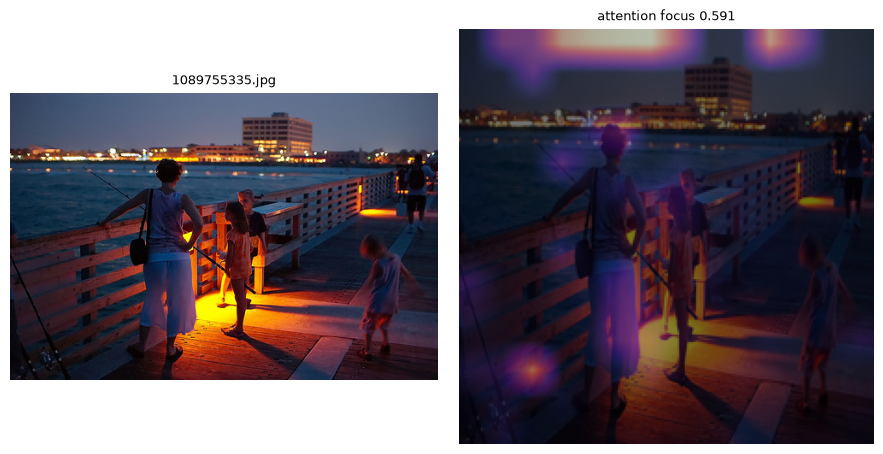

Mode: story | total 10.07s | stages {'preprocess': 0.004, 'encode': 0.012, 'caption': 0.225, 'semantics': 0.157, 'text:short_description': 0.5, 'text:detailed_explanation': 1.52, 'text:story': 7.65, 'total': 10.07}
Caption:      A man and a woman are standing on a pier looking at the water .  (confidence 0.448)
Entities:     [('man', 'person', 1, 0.34), ('woman', 'person', 1, 0.74), ('pier', 'object', 1, 0.283), ('water', 'location', 1, 0.767)]
Actions:      [('man', 'stand', None, [['on', 'pier']]), ('man', 'look', None, [['at', 'water']])]
Scene:        {'locations': [{'location': 'water', 'prep': 'at', 'setting': 'outdoor'}], 'setting': 'outdoor', 'cues': []}
Flags:        ['greedy/beam disagreement (Jaccard 0.29)']
Short description:A man and a woman stand on a pier overlooking the water.
              grounded 1.0 | coverage 1.0 | new characters 0 | new places 0 | new details 0 | repairs 0
Detailed explanation:A man and a woman are standing on a pier near the water. The man appear

In [9]:
def run_pipeline(source, mode="story", num_beams=None, seed=None):
    if mode not in CONFIG["output_modes"]:
        raise ValueError(f"unknown mode '{mode}', expected one of {list(CONFIG['output_modes'])}")
    stages = CONFIG["output_modes"][mode]
    timings = {}
    total_start = time.time()

    start = time.time()
    pixels, image = preprocess(source)
    timings["preprocess"] = time.time() - start
    name = Path(source).name if isinstance(source, (str, Path)) else "in-memory image"

    start = time.time()
    encoding = encode_image(pixels)
    timings["encode"] = time.time() - start

    start = time.time()
    caption = generate_caption(encoding["prefix"], num_beams=num_beams)
    timings["caption"] = time.time() - start

    result = {"image": name, "mode": mode, "caption": caption, "attention_focus": encoding["attention_focus"], "attention": encoding["attention"], "pil_image": image}

    if "semantics" in stages:
        start = time.time()
        greedy = generate_caption(encoding["prefix"], num_beams=1)
        pieces, confidence = caption_pieces(pixels, caption)
        result["record"] = analyze_caption(name, caption, greedy, pieces)
        result["caption_confidence"] = confidence
        timings["semantics"] = time.time() - start

    text_modes = [s for s in stages if s in STORY_STRUCTURE]
    if text_modes:
        texts, reports, text_timings = narrate_record(result["record"], outputs=tuple(text_modes), seed=seed)
        result["texts"] = texts
        result["grounding"] = reports
        timings.update({f"text:{k}": v for k, v in text_timings.items()})

    timings["total"] = time.time() - total_start
    result["timings"] = {k: round(v, 3) for k, v in timings.items()}
    return result

def render(result, show_attention=True):
    cols = 2 if show_attention else 1
    fig, axes = plt.subplots(1, cols, figsize=(4.5 * cols, 4.5))
    axes = np.atleast_1d(axes)
    axes[0].imshow(result["pil_image"])
    axes[0].set_title(result["image"], fontsize=9)
    if show_attention:
        small = result["pil_image"].resize((IMG_SIZE, IMG_SIZE))
        heat = np.asarray(Image.fromarray((result["attention"] / result["attention"].max() * 255).astype(np.uint8)).resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)) / 255.0
        axes[1].imshow(small)
        axes[1].imshow(heat, cmap="magma", alpha=0.55)
        axes[1].set_title(f"attention focus {result['attention_focus']}", fontsize=9)
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()
    print(f"Mode: {result['mode']} | total {result['timings']['total']:.2f}s | stages {result['timings']}")
    print(f"Caption:      {result['caption']}" + (f"  (confidence {result['caption_confidence']})" if "caption_confidence" in result else ""))
    if "record" in result:
        rec = result["record"]
        print(f"Entities:     {[(e['lemma'], e['type'], e['count'], e['confidence']) for e in rec['semantics']['entities']]}")
        print(f"Actions:      {[(a['subject'], a['verb'], a['object'], a['prep_objects']) for a in rec['semantics']['actions']]}")
        print(f"Scene:        {rec['semantics']['scene']}")
        print(f"Flags:        {rec['flags'] or 'none'}")
    for mode, text in result.get("texts", {}).items():
        report = result["grounding"][mode]
        print(f"{mode.replace('_', ' ').capitalize() + ':':<14}{text}")
        print(f"{'':<14}grounded {report['grounded_ratio']} | coverage {report['entity_coverage']} | new characters {report['new_characters']} | new places {report['new_places']} | new details {report['new_details']} | repairs {report['repairs']}")

result = run_pipeline(sample_path)
render(result)


## 12. End-to-End Demonstrations

Images that no earlier notebook processed: src/data/demo/* when present, otherwise test images beyond the first 40.

Each demonstration shows the image, the ViT attention map, the caption with its confidence, the extracted semantics, and the short description / explanation / story with grounding scores.


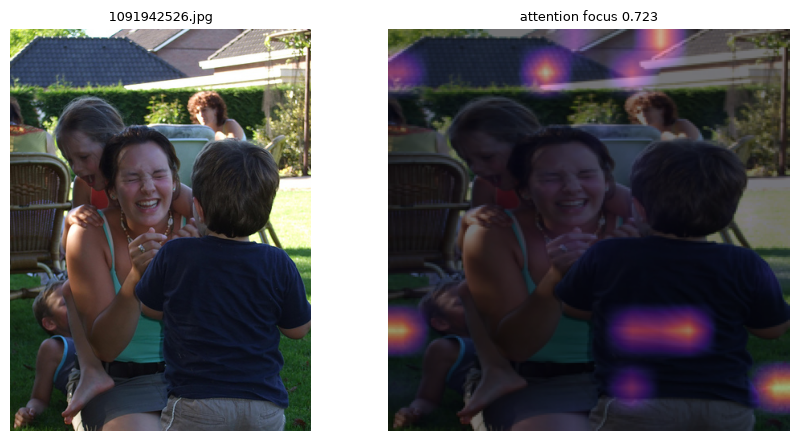

Mode: story | total 9.01s | stages {'preprocess': 0.003, 'encode': 0.015, 'caption': 0.267, 'semantics': 0.118, 'text:short_description': 0.54, 'text:detailed_explanation': 1.05, 'text:story': 7.01, 'total': 9.006}
Caption:      A woman in a green shirt is holding a young girl in a blue shirt .  (confidence 0.427)
Entities:     [('woman', 'person', 1, 0.589), ('girl', 'person', 1, 0.32)]
Actions:      [('woman', 'hold', 'girl', [['in', 'shirt']])]
Scene:        {'locations': [], 'setting': 'unknown', 'cues': []}
Flags:        ['repeated bigram', 'greedy/beam disagreement (Jaccard 0.25)']
Short description:A woman in a green shirt holds a young girl in a blue shirt.
              grounded 1.0 | coverage 1.0 | new characters 0 | new places 0 | new details 0 | repairs 0
Detailed explanation:A woman in a green shirt holds a young girl in a blue shirt. The relationship between them is uncertain due to a small overlap in their clothing colors.
              grounded 0.75 | coverage 1.0 | new

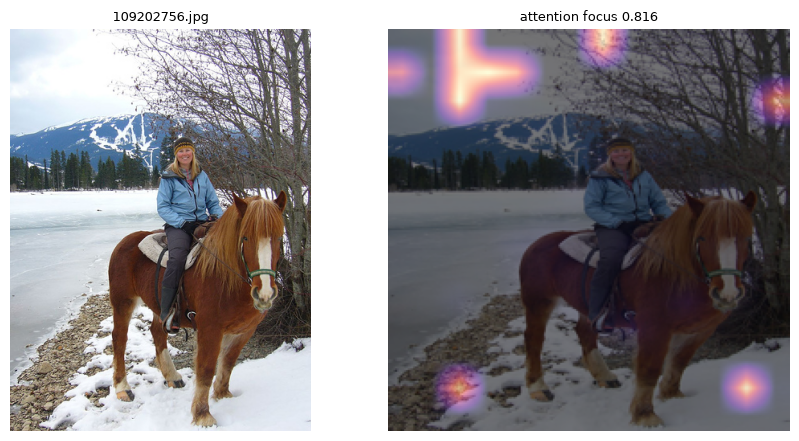

Mode: story | total 8.14s | stages {'preprocess': 0.005, 'encode': 0.01, 'caption': 0.2, 'semantics': 0.124, 'text:short_description': 0.4, 'text:detailed_explanation': 0.46, 'text:story': 6.94, 'total': 8.144}
Caption:      A woman in a blue jacket is sitting on a horse .  (confidence 0.573)
Entities:     [('woman', 'person', 1, 0.674), ('horse', 'animal', 1, 0.618)]
Actions:      [('woman', 'sit', None, [['on', 'horse']])]
Scene:        {'locations': [], 'setting': 'unknown', 'cues': []}
Flags:        none
Short description:A woman in a blue jacket sits on a horse.
              grounded 1.0 | coverage 1.0 | new characters 0 | new places 0 | new details 0 | repairs 0
Detailed explanation:A woman in a blue jacket is sitting on a horse.
              grounded 1.0 | coverage 1.0 | new characters 0 | new places 0 | new details 0 | repairs 0
Story:        The sun was shining brightly on a warm summer day as the woman in a blue jacket sat on her trusty steed, the horse. She leaned back int

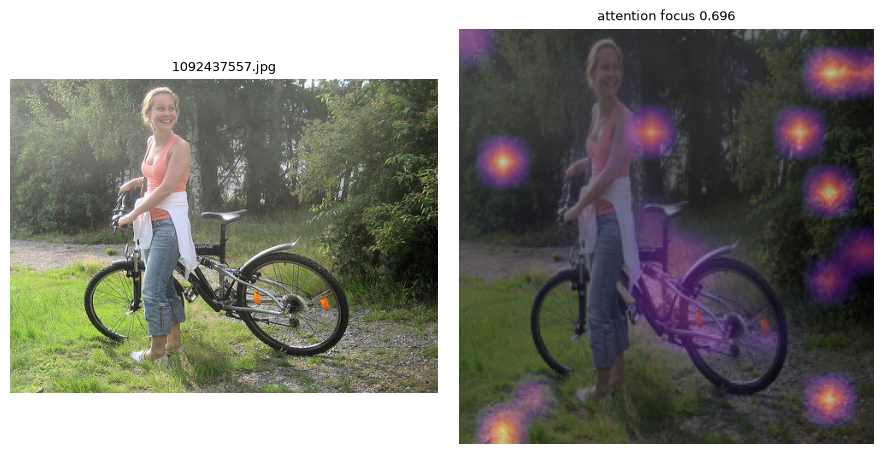

Mode: story | total 3.99s | stages {'preprocess': 0.005, 'encode': 0.009, 'caption': 0.192, 'semantics': 0.142, 'text:short_description': 0.51, 'text:detailed_explanation': 0.98, 'text:story': 2.16, 'total': 3.989}
Caption:      A woman in a pink shirt and jeans is standing on a bicycle .  (confidence 0.498)
Entities:     [('woman', 'person', 1, 0.445), ('bicycle', 'object', 1, 0.399)]
Actions:      [('woman', 'stand', None, [['on', 'bicycle']])]
Scene:        {'locations': [], 'setting': 'unknown', 'cues': []}
Flags:        ['greedy/beam disagreement (Jaccard 0.33)']
Short description:A woman stands on a bicycle in a pink shirt and jeans.
              grounded 1.0 | coverage 1.0 | new characters 0 | new places 0 | new details 0 | repairs 0
Detailed explanation:A woman in a pink shirt and jeans stands on a bicycle. The caption accurately describes her appearance and action without adding any additional details.
              grounded 0.875 | coverage 1.0 | new characters 0 | new place

In [10]:
demo_dir = CONFIG["paths"]["demo"]
demo_paths = sorted(p for p in demo_dir.glob("*") if p.suffix.lower() in (".jpg", ".jpeg", ".png")) if demo_dir.exists() else []
if len(demo_paths) < 3:
    demo_paths += [Path(p) for p in test_paths.iloc[41:44]]
demo_paths = demo_paths[:3]

demo_results = []
for path in demo_paths:
    result = run_pipeline(path)
    demo_results.append(result)
    render(result)
    print("=" * 110)


## 13. Different Output Modes

| Mode | Stages | Typical use |
|---|---|---|
| caption | preprocess → encode → caption | fastest, alt-text |
| describe | + semantics + short description | one clean sentence with confidence markers |
| explain | + detailed explanation | factual paragraph |
| story | + story | narrative with grounding check |
| structured | caption + semantic record as JSON | downstream systems |

Also shown: greedy vs beam decoding for the caption stage.


In [11]:
mode_rows = []
mode_outputs = {}
for mode in CONFIG["output_modes"]:
    result = run_pipeline(sample_path, mode=mode)
    mode_outputs[mode] = result
    output = result["caption"] if mode == "caption" else (json.dumps(result["record"]["semantics"]["entities"]) if mode == "structured" else result["texts"][CONFIG["output_modes"][mode][-1]])
    mode_rows.append({"mode": mode, "stages": len(CONFIG["output_modes"][mode]), "total s": result["timings"]["total"], "last output": output[:110]})
display(pd.DataFrame(mode_rows))

print("structured mode record:")
print(json.dumps({k: v for k, v in mode_outputs["structured"]["record"].items() if k in ("caption", "semantics", "flags", "prompt")}, indent=2)[:1500])

decoding_rows = []
for beams in (1, 3, cap_cfg["num_beams"]):
    result = run_pipeline(sample_path, mode="caption", num_beams=beams)
    decoding_rows.append({"num_beams": beams, "caption": result["caption"], "caption s": result["timings"]["caption"]})
display(pd.DataFrame(decoding_rows))


,mode,stages,total s,last output
0,caption,1,0.249,A man and a woman are standing on a pier looking at the water .
1,describe,3,0.887,A man and a woman stand on a pier overlooking the water.
2,explain,4,2.426,A man and a woman are standing on a pier near the water. The man appears to be standin...
3,story,5,10.370,A man and a woman stand on a pier overlooking a vast expanse of water. The sun casts l...
4,structured,2,0.404,"[{""id"": 0, ""text"": ""A man"", ""lemma"": ""man"", ""type"": ""person"", ""count"": 1, ""plural"": fa..."


structured mode record:
{
  "caption": "A man and a woman are standing on a pier looking at the water .",
  "semantics": {
    "entities": [
      {
        "id": 0,
        "text": "A man",
        "lemma": "man",
        "type": "person",
        "count": 1,
        "plural": false,
        "token": 1,
        "confidence": 0.34
      },
      {
        "id": 1,
        "text": "a woman",
        "lemma": "woman",
        "type": "person",
        "count": 1,
        "plural": false,
        "token": 4,
        "confidence": 0.74
      },
      {
        "id": 2,
        "text": "a pier",
        "lemma": "pier",
        "type": "object",
        "count": 1,
        "plural": false,
        "token": 9,
        "confidence": 0.283
      },
      {
        "id": 3,
        "text": "the water",
        "lemma": "water",
        "type": "location",
        "count": 1,
        "plural": false,
        "token": 13,
        "confidence": 0.767
      }
    ],
    "actions": [
      {
       

c:\Users\vishe\OneDrive\Desktop\VisionNarrator\VisionNarrator\venv\Lib\site-packages\transformers\generation\utils.py:1185: UserWarning: Passing `no_repeat_ngram_size` with `inputs_embeds` and without `input_ids` to `generate` will apply n-gram constraints only to newly generated tokens, not to the prompt.
  warnings.warn(


,num_beams,caption,caption s
0,1,A man and a woman are standing on a dock with a boat in the background .,0.182
1,3,A man and a woman are looking at the water .,0.229
2,5,A man and a woman are standing on a pier looking at the water .,0.221


## 14. Error Handling

`safe_run` wraps the pipeline: every failure is returned as a structured result (ok, stage, error) instead of an exception, and the GPU is left in a clean state.

Cases exercised (synthetic files are written to a temporary directory): missing file · text file with an image extension · truncated JPEG · 1×1 image · grayscale image · RGBA image · extreme aspect ratio · unknown output mode · NumPy array input · wrong input type · story model unavailable (fallback texts).


In [12]:
def safe_run(source, **kwargs):
    stage = "load"
    try:
        stage = "pipeline"
        result = run_pipeline(source, **kwargs)
        return {"ok": True, "image": result["image"], "caption": result["caption"], "result": result}
    except (FileNotFoundError, ValueError, TypeError) as error:
        return {"ok": False, "stage": stage, "error": f"{type(error).__name__}: {error}"}
    except torch.OutOfMemoryError as error:
        if device.type == "cuda":
            torch.cuda.empty_cache()
        return {"ok": False, "stage": "gpu", "error": f"OutOfMemoryError: {str(error)[:120]}"}
    except Exception as error:
        return {"ok": False, "stage": stage, "error": f"{type(error).__name__}: {str(error)[:160]}"}

scratch = Path(tempfile.mkdtemp(prefix="visionnarrator_error_cases_"))
(scratch / "not_an_image.jpg").write_text("this is a text file pretending to be a jpeg", encoding="utf-8")
(scratch / "truncated.jpg").write_bytes(sample_path.read_bytes()[:2000])
Image.new("RGB", (1, 1)).save(scratch / "tiny.png")
sample_image.convert("L").save(scratch / "grayscale.png")
sample_image.convert("RGBA").save(scratch / "rgba.png")
sample_image.resize((900, 60)).save(scratch / "panorama.jpg")

cases = [
    ("missing file", scratch / "does_not_exist.jpg", {}),
    ("text file named .jpg", scratch / "not_an_image.jpg", {}),
    ("truncated jpeg", scratch / "truncated.jpg", {}),
    ("1x1 image", scratch / "tiny.png", {}),
    ("grayscale image", scratch / "grayscale.png", {"mode": "caption"}),
    ("rgba image", scratch / "rgba.png", {"mode": "caption"}),
    ("900x60 panorama", scratch / "panorama.jpg", {"mode": "caption"}),
    ("unknown mode", sample_path, {"mode": "poem"}),
    ("numpy array input", np.asarray(sample_image), {"mode": "caption"}),
    ("wrong input type", 12345, {}),
]
rows = []
for label, source, kwargs in cases:
    outcome = safe_run(source, **kwargs)
    rows.append({"case": label, "ok": outcome["ok"], "caption": outcome.get("caption", ""), "stage": outcome.get("stage", ""), "error": outcome.get("error", "")})
display(pd.DataFrame(rows))

fallback_story = StoryGenerator(CONFIG["story_model_name"], device=device, load=False)
fallback_text = fallback_story.generate(record, "short_description")
print(f"Story model unavailable → short description falls back to the caption: {fallback_text}")


c:\Users\vishe\OneDrive\Desktop\VisionNarrator\VisionNarrator\venv\Lib\site-packages\transformers\generation\utils.py:1185: UserWarning: Passing `no_repeat_ngram_size` with `inputs_embeds` and without `input_ids` to `generate` will apply n-gram constraints only to newly generated tokens, not to the prompt.
  warnings.warn(


,case,ok,caption,stage,error
0,missing file,False,,pipeline,FileNotFoundError: image not found: C:\Users\vishe\AppData\Local\Temp\visionnarrator_e...
1,text file named .jpg,False,,pipeline,ValueError: not a readable image: not_an_image.jpg (cannot identify image file 'C:\\Us...
2,truncated jpeg,False,,pipeline,ValueError: not a readable image: truncated.jpg (Truncated File Read)
3,1x1 image,False,,pipeline,ValueError: image too small: 1x1
4,grayscale image,True,A man and a woman are standing on a pier looking at the water .,,
5,rgba image,True,A man and a woman are standing on a pier looking at the water .,,
6,900x60 panorama,True,A man and a woman are standing on a pier looking at the water .,,
7,unknown mode,False,,pipeline,"ValueError: unknown mode 'poem', expected one of ['caption', 'describe', 'explain', 's..."
8,numpy array input,True,A man and a woman are standing on a pier looking at the water .,,
9,wrong input type,False,,pipeline,TypeError: unsupported image source type: int


Story model unavailable → short description falls back to the caption: A man and a woman are standing on a pier looking at the water .


## 15. Performance Analysis

Stage latencies over PERF_NUM_IMAGES test images (mean / median / p95), GPU peak memory, throughput, and the cost of options: greedy vs beam captions, and caption-only vs full story mode.


c:\Users\vishe\OneDrive\Desktop\VisionNarrator\VisionNarrator\venv\Lib\site-packages\transformers\generation\utils.py:1185: UserWarning: Passing `no_repeat_ngram_size` with `inputs_embeds` and without `input_ids` to `generate` will apply n-gram constraints only to newly generated tokens, not to the prompt.
  warnings.warn(


,mean s,median s,p95 s
preprocess,0.005,0.005,0.006
encode,0.010,0.010,0.013
caption,0.235,0.228,0.285
semantics,0.120,0.124,0.144
text:short_description,0.458,0.430,0.654
text:detailed_explanation,1.588,1.350,3.430
text:story,7.370,7.145,9.614
total,9.787,9.368,12.512


Throughput (story mode): 6.1 images / min
GPU peak memory during the run: 4.09 GB


c:\Users\vishe\OneDrive\Desktop\VisionNarrator\VisionNarrator\venv\Lib\site-packages\transformers\generation\utils.py:1185: UserWarning: Passing `no_repeat_ngram_size` with `inputs_embeds` and without `input_ids` to `generate` will apply n-gram constraints only to newly generated tokens, not to the prompt.
  warnings.warn(


,option,mean s
0,"caption, greedy",0.190
1,"caption, beam",0.241
2,describe,0.842
3,story,11.246


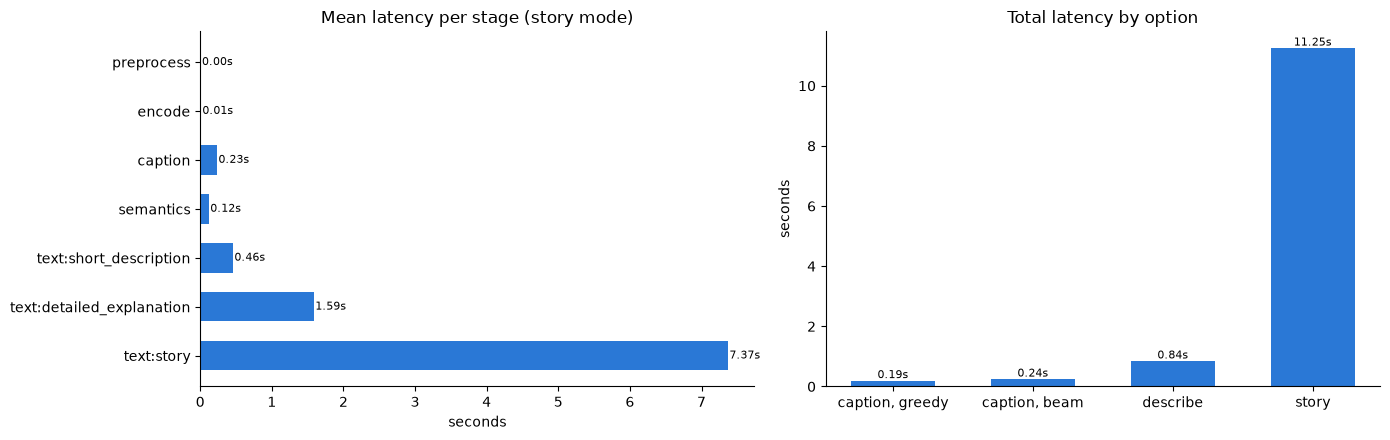

In [13]:
PERF_NUM_IMAGES = 8
perf_paths = [Path(p) for p in test_paths.iloc[50 : 50 + PERF_NUM_IMAGES]]

if device.type == "cuda":
    torch.cuda.reset_peak_memory_stats()

perf_rows = []
for path in perf_paths:
    result = run_pipeline(path, mode="story")
    perf_rows.append(result["timings"])
perf_df = pd.DataFrame(perf_rows)

latency = pd.DataFrame({"mean s": perf_df.mean(), "median s": perf_df.median(), "p95 s": perf_df.quantile(0.95)}).round(3)
display(latency)

print(f"Throughput (story mode): {60 / perf_df['total'].mean():.1f} images / min")
if device.type == "cuda":
    print(f"GPU peak memory during the run: {torch.cuda.max_memory_allocated() / 1e9:.2f} GB")

option_rows = []
for label, kwargs in [("caption, greedy", {"mode": "caption", "num_beams": 1}), ("caption, beam", {"mode": "caption"}), ("describe", {"mode": "describe"}), ("story", {"mode": "story"})]:
    totals = [run_pipeline(path, **kwargs)["timings"]["total"] for path in perf_paths[:4]]
    option_rows.append({"option": label, "mean s": round(float(np.mean(totals)), 3)})
options_df = pd.DataFrame(option_rows)
display(options_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
stages = [c for c in perf_df.columns if c != "total"]
axes[0].barh(stages[::-1], perf_df[stages].mean()[::-1], color="#2a78d6", height=0.6)
for y, v in enumerate(perf_df[stages].mean()[::-1]):
    axes[0].text(v + 0.02, y, f"{v:.2f}s", va="center", fontsize=8)
axes[0].set_title("Mean latency per stage (story mode)")
axes[0].set_xlabel("seconds")
axes[1].bar(options_df["option"], options_df["mean s"], color="#2a78d6", width=0.6)
for x, v in enumerate(options_df["mean s"]):
    axes[1].text(x, v, f"{v:.2f}s", ha="center", va="bottom", fontsize=8)
axes[1].set_title("Total latency by option")
axes[1].set_ylabel("seconds")
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## 16. Final System Summary

Components → evaluation results (Notebook 07) → semantic and story statistics (Notebooks 08/09) → pipeline latency, gathered into one table and saved:

results/final_system_summary.json
docs/final_system_summary.md

What works: a fully local pipeline from pixels to grounded narrative; every stage measurable; every generated element traceable to the caption through the structured record and the grounding report.

Limitations: caption quality bounds everything downstream (rare objects, counts, generic captions); the semantic layer is rule-based on top of a small parser; a 1.5B story model still adds details (sun, sky, sidewalk) and occasionally echoes prompt wording; latency is dominated by story generation.

Next steps: larger or better-aligned story model, CIDEr-optimised decoding or a stronger captioner backbone, learned scene-graph extraction, and a small web UI around `run_pipeline`.


In [14]:
def load_json(path):
    return json.load(open(path, encoding="utf-8")) if Path(path).exists() else None

def load_csv(path):
    return pd.read_csv(path) if Path(path).exists() else None

results_dir = CONFIG["paths"]["results"]
evaluation = load_json(results_dir / "evaluation_metrics.json")
semantic_summary = load_csv(results_dir / "semantic_summary.csv")
story_summary = load_csv(results_dir / "story_generation_summary.csv")

summary = {
    "components": components,
    "captioner": CONFIG["captioner"],
    "story_model": {"name": CONFIG["story_model_name"], "available": story.available, "settings": CONFIG["story"]},
    "evaluation": None if evaluation is None else {"test_images": evaluation["test_set"]["images"], "best_decoding": evaluation["best_decoding"], "metrics": evaluation["metrics"], "comparison_subset": evaluation["comparison_subset"]},
    "semantic_layer": None if semantic_summary is None else {"images": int(len(semantic_summary)), "mean_entities": round(float(semantic_summary["entities"].mean()), 2), "mean_actions": round(float(semantic_summary["actions"].mean()), 2), "images_with_flags": int((semantic_summary["flags"] > 0).sum())},
    "story_generation": None if story_summary is None else {"records": int(len(story_summary)), "mean_story_grounded_ratio": round(float(story_summary["story_grounded_ratio"].mean()), 3), "mean_story_entity_coverage": round(float(story_summary["story_entity_coverage"].mean()), 3), "stories_with_names": int((story_summary["story_names"] > 0).sum()), "stories_repaired": int((story_summary["story_repairs"] > 0).sum())},
    "pipeline_latency": {"images": PERF_NUM_IMAGES, "mean_total_s": round(float(perf_df["total"].mean()), 3), "stages_mean_s": {k: round(float(v), 3) for k, v in perf_df.mean().items()}, "options_mean_s": {row["option"]: row["mean s"] for row in option_rows}},
    "device": CONFIG["device"],
}

rows = {
    "Captioner": f"{CONFIG['captioner']['vit_model_name']} + {CONFIG['captioner']['gpt2_model_name']} | best phase {CONFIG['captioner']['best_phase']} | val loss {CONFIG['captioner']['val_loss']}",
    "Story model": f"{CONFIG['story_model_name']} ({'loaded' if story.available else 'unavailable'})",
    "Test images evaluated": summary["evaluation"]["test_images"] if evaluation else "n/a",
}
if evaluation:
    best = evaluation["best_decoding"]
    rows.update({f"{k} ({best})": v for k, v in evaluation["metrics"][best].items()})
    rows["BLEU-4 vs previous best (500 imgs)"] = f"{evaluation['comparison_subset']['final_model_bleu4']} vs {evaluation['comparison_subset']['previous_best_bleu4']} ({evaluation['comparison_subset']['previous_best_model']})"
if summary["semantic_layer"]:
    rows["Semantic layer (mean entities / actions per image)"] = f"{summary['semantic_layer']['mean_entities']} / {summary['semantic_layer']['mean_actions']}"
if summary["story_generation"]:
    rows["Story grounded ratio / entity coverage"] = f"{summary['story_generation']['mean_story_grounded_ratio']} / {summary['story_generation']['mean_story_entity_coverage']}"
rows["Pipeline latency (story mode, mean)"] = f"{summary['pipeline_latency']['mean_total_s']} s"
rows["Pipeline latency (caption only, mean)"] = f"{summary['pipeline_latency']['options_mean_s'].get('caption, beam', 'n/a')} s"
display(pd.Series(rows).to_frame("value"))

CONFIG["paths"]["results"].mkdir(exist_ok=True)
CONFIG["paths"]["docs"].mkdir(exist_ok=True)
summary_json_path = results_dir / "final_system_summary.json"
summary_md_path = CONFIG["paths"]["docs"] / "final_system_summary.md"
with open(summary_json_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, default=str)
lines = ["# VisionNarrator - Final System Summary", ""]
lines += [f"- **{k}:** {v}" for k, v in rows.items()]
lines += ["", "## Components", "", "| component | parameters | disk MB | device | load s |", "|---|---|---|---|---|"]
lines += [f"| {c['component']} | {c['parameters'] if c['parameters'] else '-'} | {c['disk MB'] if c['disk MB'] else '-'} | {c['device']} | {c['load s']} |" for c in components]
lines += ["", "## Stage latency (story mode, mean seconds)", ""]
lines += [f"- {k}: {v}" for k, v in summary["pipeline_latency"]["stages_mean_s"].items()]
summary_md_path.write_text("\n".join(lines) + "\n", encoding="utf-8")

print(f"Saved: {summary_json_path}")
print(f"Saved: {summary_md_path}")


,value
Captioner,google/vit-base-patch16-224-in21k + gpt2 | best phase phase3 | val loss 2.3656
Story model,Qwen/Qwen2.5-1.5B-Instruct (loaded)
Test images evaluated,4768
BLEU-1 (beam 5),0.7082
BLEU-2 (beam 5),0.5142
BLEU-3 (beam 5),0.3718
BLEU-4 (beam 5),0.2675
METEOR (beam 5),0.2285
ROUGE-L (beam 5),0.5362
CIDEr (beam 5),0.6038


Saved: C:\Users\vishe\OneDrive\Desktop\VisionNarrator\VisionNarrator\results\final_system_summary.json
Saved: C:\Users\vishe\OneDrive\Desktop\VisionNarrator\VisionNarrator\docs\final_system_summary.md
